# 03 · Deep Researcher Agent

**Goal:** turn a ranked list of skill gaps into **personalized learning pathways** — courses, projects, checklists — grounded in current web knowledge via Tavily search.

This is the offline research log for the agent. The same architecture ships in the backend (`backend/app/deep_researcher`), but here we keep things self-contained and explanatory: each section starts with *why* the design choice matters, then shows *how*. Inputs are dummy `GapIn` records (in production they come from the Gap Analysis agent).

```
        ┌─────────────── Deep Researcher LangGraph ───────────────┐
Gap ───▶│  plan ⇄ search  →  critic                                │
list    │                       │                                  │
        │                       ▼                                  │
        │                  structure  →  validate  →  judge ──┐    │
        └───────────────────────────────────────────▲────────┼────┘
                                                    │        ▼
                                                  retry ◀── fail
                                                             pass → END
```

**Design highlights**

- **Plan ↔ search loop** with an LLM `continue | structure` router. Hard-cap on iterations as a budget guard.
- **Recursive Pydantic output** (`Pathway → Milestone[] → Resource[]`) so the structurer emits the whole tree in one structured call.
- **In-graph link validation** — every resource URL must trace back to the research notes (no hallucinated links), then survives an HTTP liveness probe.
- **In-graph judge with retry** — a separate-temperature Groq judge scores the pathway on a 7-criterion rubric; on `fail`, its `improvement_actions` feed back into the structurer prompt for one retry.
- **All Groq** (`llama-3.3-70b-versatile`) — single provider for planner, critic, structurer, and judge. Keeps cost + behavior consistent.

The final section adds **trajectory / drift testing** — we score the *path through the graph*, not just the final pathway, because a probabilistic system can produce a passable answer via a degenerate route.

## 0. Setup

Offline experimental notebook. We pull secrets from `../backend/.env` so this notebook and the backend share one source of truth. Kernel: the backend `uv` venv (`backend/.venv`) — it already has `langchain-groq`, `tavily-python`, `langgraph`, `httpx`, `pydantic`, `python-dotenv`.

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path("../backend/.env").resolve())

# Jupyter runs its own asyncio loop; nest_asyncio lets validate_pathway
# call asyncio.run() from inside a sync node without the running-loop error.
import nest_asyncio
nest_asyncio.apply()
assert os.getenv("TAVILY_API_KEY"), "Missing TAVILY_API_KEY in backend/.env"
assert os.getenv("GROQ_API_KEY"),   "Missing GROQ_API_KEY in backend/.env"
print("OK")

OK


## 1. Tools — recency-filtered Tavily

A deep researcher that recommends `PyTorch 0.4` tutorials or expired Coursera courses fails the job. **Recency is correctness**, not a nice-to-have. We restrict search to the last year (`time_range="year"`) so the planner never surfaces deprecated framework versions.

We call `tavily.TavilyClient` directly (not the LangChain wrapper) to keep control of the result shape — we want `published_date` and `score` available downstream, not just `url` + `content`.

In [2]:
from typing import List, Dict, Optional
from tavily import TavilyClient


def tavily_search(
    query: str,
    *,
    max_results: int = 5,
    search_depth: str = "advanced",
    topic: str = "general",
    time_range: Optional[str] = "year",  # "day" | "week" | "month" | "year"
) -> List[Dict]:
    """Run a Tavily search and normalize to {url, title, content, score, published_date}."""
    try:
        client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
        kwargs = {"max_results": max_results, "search_depth": search_depth, "topic": topic}
        if time_range:
            kwargs["time_range"] = time_range
        raw = client.search(query, **kwargs)
    except Exception as e:
        print(f"Tavily search failed: {e}")
        return []

    results = raw.get("results", []) if isinstance(raw, dict) else (raw or [])
    return [
        {
            "url": r.get("url", ""),
            "title": r.get("title", ""),
            "content": r.get("content", "") or "",
            "score": r.get("score"),
            "published_date": r.get("published_date"),
        }
        for r in results if isinstance(r, dict)
    ]

In [3]:
# Smoke test — confirm Tavily is reachable and the schema looks right.
sample = tavily_search("best PyTorch course 2025 for production ML", max_results=3)
print(f"{len(sample)} results")
for r in sample[:2]:
    print(f"  • {r['url']}")
    print(f"    published: {r['published_date']}  score: {r['score']}")
    print(f"    {r['content'][:120]}...")

3 results
  • https://www.linkedin.com/posts/agrigorev_why-choose-pytorch-over-keras-for-deep-learning-activity-7389986203674038273-Z_Xe
    published: None  score: 0.6793707
    Why choose PyTorch over Keras for deep learning in 2025? Keras still holds its ground. It's fantastic for education, pro...
  • https://tech-insider.org/pytorch-tutorial-deep-learning-complete-guide-2026
    published: None  score: 0.64478505
    ## PyTorch vs TensorFlow in 2026: Why PyTorch Dominates

The PyTorch vs TensorFlow debate has shifted decisively in PyTo...


## 2. Output schema — recursive Pydantic tree

A learning pathway is naturally a tree: `Pathway → Milestone[] → Resource[]`. Emitting the whole tree in one structured-output call gives us automatic validation *and* a single LLM round-trip (no glue code stitching independent calls together).

**Why `Resource.kind` is `str` and not `Literal[...]`** — Groq's strict structured-output mode is picky with enums; a `str` field with a `description=` lets the model pick a sensible kind while staying within the schema. We accept a tiny variance in spelling in exchange for not failing structured output on every run.

Then we lay out the *intermediate* schemas (planner output, critic decision, judge verdict) and the LangGraph `ResearcherState` — one TypedDict that flows through every node.

In [4]:
from typing import List, Literal, Optional, TypedDict
from pydantic import BaseModel, Field


# ── Output tree ──────────────────────────────────────────────────────────────

class Resource(BaseModel):
    title: str
    kind: str = Field(
        description="Resource type: course, doc, video, article, project, blog, tutorial, book"
    )
    provider: str = Field(description="e.g. Coursera, YouTube, official docs, fast.ai")
    url: str
    why: str = Field(description="1 sentence — why this resource for this milestone")


class Milestone(BaseModel):
    phase: Literal["Foundations", "Intermediate", "Advanced"]
    skill: str = Field(description="Gap skill being closed")
    estimated_weeks: int
    objective: str = Field(description="What the learner will be able to do after this milestone")
    resources: List[Resource] = Field(default_factory=list)
    checklist: List[str] = Field(description="3-5 concrete, checkable items")
    mini_project: Optional[str] = Field(None, description="Hands-on project suggestion")


class Pathway(BaseModel):
    target_role: str
    milestones: List[Milestone]
    rationale: str = Field(description="2-3 sentence reasoning on why the ordering works")


# ── Input gap shape (mirrors notebook 02's Gap output) ───────────────────────

class GapIn(BaseModel):
    skill: str
    category: str
    relevance: int
    difficulty: str
    prerequisites: List[str] = Field(default_factory=list)
    why: str = ""
    level_required: str = "intermediate"


# ── Intermediate LLM outputs ─────────────────────────────────────────────────

class NextQuery(BaseModel):
    query: str = Field(description="The single best next search query — concise, 6-15 words")
    rationale: str = Field(description="Why this query, 1 sentence")


class CriticOut(BaseModel):
    decision: Literal["continue", "structure"]
    rationale: str


# ── Evaluation: LLM as judge ─────────────────────────────────────────────────

JudgeCriterion = Literal[
    "coverage",          # every gap addressed
    "ordering",          # prerequisite logic respected
    "resource_quality",  # real, relevant, role-aligned
    "actionability",     # checklist + project concrete
    "personalization",   # plan reflects role + user gaps
    "grounding",         # claims/links trace to notes
    "recency",           # resources current, not deprecated
]


class JudgeScore(BaseModel):
    criterion: JudgeCriterion
    score: int = Field(ge=1, le=5)
    rationale: str = Field(description="One concise reason with evidence")


class JudgeVerdict(BaseModel):
    overall_score: float = Field(ge=1, le=5)
    pass_fail: Literal["pass", "fail"]
    strengths: List[str] = Field(default_factory=list)
    weaknesses: List[str] = Field(default_factory=list)
    improvement_actions: List[str] = Field(
        default_factory=list,
        description="Concrete fixes the structurer should apply on a retry",
    )
    rubric_scores: List[JudgeScore] = Field(default_factory=list)
    confidence: Literal["low", "medium", "high"] = "medium"


# ── Validation: grounding + liveness ─────────────────────────────────────────

class DroppedResource(BaseModel):
    milestone_skill: str
    title: str
    url: str
    reason: Literal["ungrounded", "dead_link"]


class ValidationResult(BaseModel):
    checked: int = 0
    kept: int = 0
    dropped: List[DroppedResource] = Field(default_factory=list)


# ── LangGraph state ──────────────────────────────────────────────────────────

class ResearcherState(TypedDict, total=False):
    gaps: List[GapIn]
    target_role: str
    notes: List[str]
    last_query: str
    iteration: int
    max_iter: int
    pathway: Pathway
    valid_urls: List[str]   # URLs Tavily actually returned — grounding source of truth
    validation: dict        # ValidationResult dump
    judge_verdict: dict     # JudgeVerdict dump
    retry_count: int        # structure re-runs triggered by judge fail
    max_retry: int

## 3. State + planner node

One Groq model instance shared by planner / critic / structurer (temperature 0.2 for some creativity in queries and pathways). The judge gets its own instance at temperature 0.0 in Section 8 — same model, different sampling, so the evaluator is more deterministic than the generator.

The planner's job: pick the **single next** search query that most improves the pathway. Iteration 0 starts on the highest-relevance gap with a freshness bias (`{current_year}`); later iterations drill into whatever gaps the notes don't yet cover.

In [5]:
from datetime import datetime
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq

CURRENT_YEAR = datetime.now().year

groq = ChatGroq(
    model="llama-3.3-70b-versatile",
    groq_api_key=os.getenv("GROQ_API_KEY"),
    temperature=0.2,
)


PLAN_PROMPT = ChatPromptTemplate.from_template('''You are a research planner for career-skill learning pathways.

TARGET ROLE: {target_role}
CURRENT YEAR: {current_year}

OUTSTANDING GAPS (skill, relevance, difficulty):
{gaps}

NOTES GATHERED SO FAR (from previous searches, newest last):
{notes}

Propose ONE next web search query that will most improve the pathway.
Rules:
- Iteration 0: start with the highest-relevance gap; seek the best CURRENT courses/docs.
- Always bias toward freshness — include "{current_year}" or "latest" in the query so
  results reflect current framework versions, not deprecated ones.
- Later iterations: cover gaps not yet represented in the notes, or drill deeper.
- Prefer concrete queries ("best PyTorch course {current_year} for production ML")
  over vague ones.''')


def _gaps_brief(gaps) -> str:
    return "\n".join(f"- {g.skill} (rel={g.relevance}, {g.difficulty})" for g in gaps)


def _notes_brief(notes, char_cap: int = 300) -> str:
    if not notes:
        return "(none yet)"
    return "\n".join(f"[{i}] {n[:char_cap]}" for i, n in enumerate(notes))


def node_plan(state: ResearcherState) -> dict:
    planner = PLAN_PROMPT | groq.with_structured_output(NextQuery)
    nxt: NextQuery = planner.invoke({
        "target_role": state["target_role"],
        "current_year": CURRENT_YEAR,
        "gaps": _gaps_brief(state["gaps"]),
        "notes": _notes_brief(state.get("notes", [])),
    })
    iteration = state.get("iteration", 0) + 1
    print(f"iter {iteration} → plan: {nxt.query}  ({nxt.rationale})")
    return {"last_query": nxt.query, "iteration": iteration}

## 4. Search node — with grounding tracking

The search node does two jobs:

1. **Append to `notes`** — what the agent has seen so far, used as context by both the critic and the structurer.
2. **Accumulate `valid_urls`** — the set of URLs Tavily actually returned. This is the *only* set the validator will accept later. If the structurer invents a URL not in this set, it's a hallucination and gets dropped.

We deliberately include `published_date` and `score` in each note line — the structurer reads these and the prompt tells it to prefer fresh sources.

In [6]:
def node_search(state: ResearcherState) -> dict:
    results = tavily_search(state["last_query"])
    lines, urls = [], []
    for r in results:
        url = r.get("url", "")
        pub = r.get("published_date") or "n/a"
        score = r.get("score")
        lines.append(
            f"{url} (published: {pub}, score: {score}) :: {(r.get('content') or '')[:500]}"
        )
        if url:
            urls.append(url)
    new_note = f"Q={state['last_query']}\n" + "\n".join(lines)
    return {
        "notes": state.get("notes", []) + [new_note],
        "valid_urls": state.get("valid_urls", []) + urls,
    }

## 5. Critic / router

After each search, decide: do we have enough to write a high-quality pathway, or do we need another round?

Why an LLM critic instead of a fixed step count: easy profiles (3 gaps, mainstream tooling) hit "enough" after one round; hard profiles (8 niche gaps) genuinely need more. A critic stops early on the easy cases and keeps going on the hard ones — fixed counts can't do that.

Hard cap on `max_iter` is still there as a safety net (Tavily quota + degenerate-loop guard).

In [7]:
CRITIC_PROMPT = ChatPromptTemplate.from_template('''You are a research critic.

TARGET ROLE: {target_role}
GAPS TO COVER:
{gaps}

NOTES GATHERED (newest last):
{notes}

Decide:
- "continue" if the notes don't yet give us enough to recommend concrete, current
  resources for EVERY gap.
- "structure" if we can now write a high-quality learning pathway with real,
  recent links for every gap.''')


def critic_route(state: ResearcherState) -> str:
    if state.get("iteration", 0) >= state.get("max_iter", 3):
        print("→ max_iter reached, forcing structure")
        return "structure"
    critic = CRITIC_PROMPT | groq.with_structured_output(CriticOut)
    out: CriticOut = critic.invoke({
        "target_role": state["target_role"],
        "gaps": "\n".join(f"- {g.skill}" for g in state["gaps"]),
        "notes": _notes_brief(state.get("notes", []), char_cap=500),
    })
    print(f"→ critic: {out.decision} — {out.rationale}")
    return out.decision

## 6. Structurer node — with revision feedback

The structurer is the one place we ask the LLM to emit the **full `Pathway` tree** in one structured-output call.

The crucial detail is the `{feedback}` slot. On the *first* pass it's empty. On a *retry* (Section 8 — the judge failed the pathway), we inject the judge's `weaknesses` and `improvement_actions` so the structurer rewrites with that context, instead of regenerating blind. This closes the loop: critique → rewrite → re-judge.

The prompt also nails grounding explicitly: every `url` MUST appear in the research notes. The validator (Section 7) enforces this — but stating it in the prompt cuts the number of hallucinated URLs the validator has to drop.

In [8]:
STRUCTURE_PROMPT = ChatPromptTemplate.from_template('''You are a senior learning-path designer.

TARGET ROLE: {target_role}
CURRENT YEAR: {current_year}

USER'S SKILL GAPS (ordered by relevance, prerequisites first):
{gaps}

RESEARCH NOTES (URLs + extracts + publish dates from authoritative sources):
{notes}

REVISION FEEDBACK (from a prior evaluation — empty on the first attempt):
{feedback}

Produce a Pathway with:
- ONE milestone per gap, in prerequisite-respecting order.
- Each milestone in an appropriate phase (Foundations / Intermediate / Advanced).
- 2-4 resources per milestone. CRITICAL: every resource `url` MUST be a URL that
  appears verbatim in the RESEARCH NOTES above. Do NOT invent or guess URLs —
  ungrounded links are dropped downstream and will fail evaluation.
- Prefer the most recent resources; avoid anything tied to an old framework version.
- A 3-5 item `checklist` of concrete actions.
- A `mini_project` that exercises the skill in context of the target role.
- `rationale`: why this ordering works for this user.
- If REVISION FEEDBACK is non-empty, address every point in it.''')


def _gaps_detailed(gaps) -> str:
    return "\n".join(
        f"- {g.skill} (rel={g.relevance}, {g.difficulty}, prereqs={g.prerequisites})"
        for g in gaps
    )


def node_structure(state: ResearcherState) -> dict:
    prior_verdict = state.get("judge_verdict")
    is_retry = prior_verdict is not None

    if is_retry:
        weaknesses = "; ".join(prior_verdict.get("weaknesses", [])) or "(none listed)"
        actions = "\n".join(f"- {a}" for a in prior_verdict.get("improvement_actions", []))
        feedback = (
            f"Previous attempt scored {prior_verdict.get('overall_score')}/5 "
            f"(verdict: {prior_verdict.get('pass_fail')}).\n"
            f"Weaknesses: {weaknesses}\n"
            f"Required fixes:\n{actions or '- improve overall quality'}"
        )
    else:
        feedback = "(none — first attempt)"

    structurer = STRUCTURE_PROMPT | groq.with_structured_output(Pathway)
    pathway: Pathway = structurer.invoke({
        "target_role": state["target_role"],
        "current_year": CURRENT_YEAR,
        "gaps": _gaps_detailed(state["gaps"]),
        "notes": "\n".join(state.get("notes", [])),
        "feedback": feedback,
    })
    out: dict = {"pathway": pathway}
    if is_retry:
        out["retry_count"] = state.get("retry_count", 0) + 1
    return out

## 7. Validation node — grounding + liveness

Two checks, both important for different reasons:

- **Grounding** — the URL must appear in `valid_urls` (the set of URLs Tavily actually returned). The notebook 03 original trusted the LLM here; we don't. LLMs invent plausible-looking URLs (`https://www.coursera.org/learn/transformers`) that have never existed. Dropping ungrounded URLs is cheap and catches a real, common failure mode.

- **Liveness** — an HTTP probe. We drop **only** explicit `4xx/5xx`. Network errors, TLS errors, timeouts, bot-filter blocks (`403` from Cloudflare) all stay UNKNOWN and the resource is kept. Reason: a legitimate Coursera page can return `403` to a bot HEAD request — nuking it would over-prune real resources. We accept some false negatives in dead-link detection to avoid false positives that wipe good content.

The retry-on-`{401, 403, 405, 429}` with a GET is for sites that don't allow HEAD but do answer GET.

In [9]:
import asyncio
import httpx

_UA = "Mozilla/5.0 (compatible; CareerAtlas/1.0; +https://careeratlas.app)"
_RETRY_GET_STATUSES = {401, 403, 405, 429}


def _norm(url: str) -> str:
    return (url or "").strip().rstrip("/").lower()


async def _probe(client: httpx.AsyncClient, url: str) -> tuple[str, bool]:
    """Return (url, is_dead). is_dead True only on an explicit 4xx/5xx."""
    try:
        r = await client.head(url, follow_redirects=True, timeout=6.0)
        if r.status_code in _RETRY_GET_STATUSES:
            r = await client.get(url, follow_redirects=True, timeout=8.0)
        return url, r.status_code >= 400
    except Exception:
        # DNS failure, timeout, TLS error, bot block — unknown, don't drop.
        return url, False


async def _probe_all(urls: list[str]) -> dict:
    if not urls:
        return {}
    async with httpx.AsyncClient(headers={"User-Agent": _UA}) as client:
        results = await asyncio.gather(*[_probe(client, u) for u in urls])
    return {u: dead for u, dead in results}


def validate_pathway(pathway: Pathway, valid_urls: list[str]) -> tuple[Pathway, ValidationResult]:
    grounded_set = {_norm(u) for u in (valid_urls or []) if u}

    all_urls: list[str] = []
    for m in pathway.milestones:
        for r in m.resources:
            if r.url:
                all_urls.append(r.url)

    grounded_urls = [u for u in all_urls if _norm(u) in grounded_set]
    dead_map = asyncio.run(_probe_all(list(set(grounded_urls))))

    dropped: list[DroppedResource] = []
    kept = 0
    new_milestones: list[Milestone] = []

    for m in pathway.milestones:
        surviving = []
        for r in m.resources:
            norm = _norm(r.url)
            if norm not in grounded_set:
                dropped.append(DroppedResource(
                    milestone_skill=m.skill, title=r.title, url=r.url, reason="ungrounded",
                ))
                continue
            if dead_map.get(r.url, False):
                dropped.append(DroppedResource(
                    milestone_skill=m.skill, title=r.title, url=r.url, reason="dead_link",
                ))
                continue
            surviving.append(r)
            kept += 1
        new_milestones.append(m.model_copy(update={"resources": surviving}))

    cleaned = pathway.model_copy(update={"milestones": new_milestones})
    return cleaned, ValidationResult(checked=len(all_urls), kept=kept, dropped=dropped)


def node_validate(state: ResearcherState) -> dict:
    cleaned, result = validate_pathway(state["pathway"], state.get("valid_urls", []))
    print(f"→ validate: checked={result.checked} kept={result.kept} dropped={len(result.dropped)}")
    return {"pathway": cleaned, "validation": result.model_dump()}

## 8. Judge node — 7-criterion rubric, in-graph, with retry

An out-of-graph judge tells you a score. An **in-graph** judge can *act on* it — its `improvement_actions` flow back into the structurer's `{feedback}` slot, and the structurer runs again with that context. One retry is usually enough to recover a pathway that failed for a fixable reason ("Milestone 3 has no mini-project", "Foundations phase missing for PyTorch") without burning unlimited budget.

The seven criteria — `coverage`, `ordering`, `resource_quality`, `actionability`, `personalization`, `grounding`, **`recency`**. Recency is the addition over the original notebook's 6: it specifically checks that resources aren't tied to deprecated framework versions or expired course pages, using the `published_date` field we plumbed through from Section 4.

The judge runs at `temperature=0.0` (separate from the structurer's `0.2`) so the verdict is reproducible.

In [10]:
judge_llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    groq_api_key=os.getenv("GROQ_API_KEY"),
    temperature=0.0,
)


JUDGE_PROMPT = ChatPromptTemplate.from_template('''You are a strict evaluator of AI-generated career learning pathways.

Score the pathway 1-5 on each rubric criterion (1=poor, 5=excellent):
1) coverage         — every user gap has a concrete milestone.
2) ordering         — milestones respect prerequisite logic.
3) resource_quality — resources are real, relevant, and role-aligned.
4) actionability    — checklists and mini-projects are concrete and doable.
5) personalization  — the plan reflects the target role and the user's specific gaps.
6) grounding        — resource links and claims trace back to the research notes.
7) recency          — resources are current; no deprecated framework versions or
                       expired/old course pages. Use the publish dates in the notes.

PASS RULE: pass only if overall_score >= 4.0 AND no single criterion is below 3.

CURRENT YEAR: {current_year}
TARGET ROLE: {target_role}

USER GAPS:
{gaps}

RESEARCH NOTES (with publish dates where available):
{notes}

LINK VALIDATION SUMMARY (resources already dropped for dead/ungrounded links):
{validation}

PATHWAY JSON:
{pathway_json}

Return a JudgeVerdict. `improvement_actions` must be concrete, specific fixes the
pathway author can apply on a retry (name the milestone and the problem).''')


NOTES_CHAR_CAP = 12000


def _validation_text(validation: ValidationResult | None) -> str:
    if not validation or not validation.dropped:
        return "(no resources dropped — all links grounded and live)"
    lines = [f"{validation.kept}/{validation.checked} resources kept; dropped:"]
    for d in validation.dropped:
        lines.append(f"  - [{d.milestone_skill}] {d.title} — {d.reason} ({d.url})")
    return "\n".join(lines)


def evaluate_pathway(
    *,
    target_role: str,
    gaps,
    notes: list[str],
    pathway: Pathway,
    validation: ValidationResult | None,
    current_year: int,
) -> JudgeVerdict:
    judge = JUDGE_PROMPT | judge_llm.with_structured_output(JudgeVerdict)
    notes_joined = "\n".join(notes or [])[:NOTES_CHAR_CAP] or "(no notes)"
    return judge.invoke({
        "current_year": current_year,
        "target_role": target_role,
        "gaps": _gaps_detailed(gaps),
        "notes": notes_joined,
        "validation": _validation_text(validation),
        "pathway_json": pathway.model_dump_json(indent=2),
    })


def node_judge(state: ResearcherState) -> dict:
    validation_dict = state.get("validation")
    verdict = evaluate_pathway(
        target_role=state["target_role"],
        gaps=state["gaps"],
        notes=state.get("notes", []),
        pathway=state["pathway"],
        validation=ValidationResult(**validation_dict) if validation_dict else None,
        current_year=CURRENT_YEAR,
    )
    print(f"→ judge: overall={verdict.overall_score:.2f} ({verdict.pass_fail})")
    return {"judge_verdict": verdict.model_dump()}


def judge_route(state: ResearcherState) -> str:
    verdict = state.get("judge_verdict", {}) or {}
    if verdict.get("pass_fail") == "pass":
        return "done"
    if state.get("retry_count", 0) >= state.get("max_retry", 1):
        print("→ judge: retry budget exhausted, accepting")
        return "done"
    print("→ judge: failed, retrying structure with feedback")
    return "retry"

## 9. Wire up the LangGraph

The full topology:

```
START → plan → search → critic_route ── continue → plan
                                    └── structure → structure → validate → judge → judge_route ── retry → structure
                                                                                              └── done  → END
```

Two conditional edges:
- `search → {continue → plan, structure → structure}` driven by the LLM critic.
- `judge → {retry → structure, done → END}` driven by the LLM judge.

Everything else is a plain edge. The state TypedDict from Section 2 carries everything between nodes.

In [11]:
from langgraph.graph import StateGraph, START, END


def _build_graph():
    g = StateGraph(ResearcherState)
    g.add_node("plan",      node_plan)
    g.add_node("search",    node_search)
    g.add_node("structure", node_structure)
    g.add_node("validate",  node_validate)
    g.add_node("judge",     node_judge)

    g.add_edge(START, "plan")
    g.add_edge("plan", "search")
    g.add_conditional_edges(
        "search",
        critic_route,
        {"continue": "plan", "structure": "structure"},
    )
    g.add_edge("structure", "validate")
    g.add_edge("validate", "judge")
    g.add_conditional_edges(
        "judge",
        judge_route,
        {"retry": "structure", "done": END},
    )
    return g.compile()


researcher = _build_graph()

d:\IITM Data Science\Career-Atlas\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


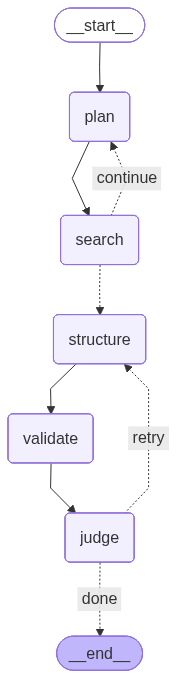

In [12]:
# Render the graph so we can see the wiring.
try:
    from IPython.display import Image, display
    display(Image(researcher.get_graph().draw_mermaid_png()))
except Exception:
    print(researcher.get_graph().draw_mermaid())

## 10. End-to-end run on dummy gaps

Dummy `GapIn` records stand in for the Gap Analysis agent's output. We feed three gaps — Transformers (highest relevance, prereq: PyTorch), PyTorch (prereq: Python + Linear Algebra), MLflow (easier, MLOps) — and let the graph plan → search → critique → structure → validate → judge. With `max_retry=1` the judge gets one shot to ask for a rewrite if the first pathway fails.

In [13]:
sample_gaps = [
    GapIn(
        skill="Transformers", category="ML", relevance=95, difficulty="Hard",
        prerequisites=["PyTorch"],
        why="Core architecture for modern NLP/LLM work; expected of every ML engineer.",
    ),
    GapIn(
        skill="PyTorch", category="ML", relevance=92, difficulty="Medium",
        prerequisites=["Python", "Linear Algebra"],
        why="Primary deep learning framework in production ML roles.",
    ),
    GapIn(
        skill="MLflow", category="MLOps", relevance=75, difficulty="Easy",
        prerequisites=["Python"],
        why="Standard for experiment tracking + model registry.",
    ),
]

state_in = {
    "gaps": sample_gaps,
    "target_role": "ml-engineer",
    "notes": [],
    "valid_urls": [],
    "iteration": 0,
    "max_iter": 3,
    "retry_count": 0,
    "max_retry": 1,
}

final = researcher.invoke(state_in, {"recursion_limit": 40})
path: Pathway = final["pathway"]

iter 1 → plan: Best 2026 courses for learning Transformers in ML  (Starting with the highest-relevance gap, seeking current courses for Transformers in 2026 to ensure freshness and relevance)
→ critic: continue — The notes only provide information on learning Transformers, but do not cover PyTorch and MLflow, therefore we cannot yet recommend concrete, current resources for every gap.
iter 2 → plan: Best 2026 courses for learning PyTorch in production ML  (Since Transformers has been partially covered, the next step is to address the second highest relevance gap, PyTorch, by seeking the best current courses for production ML in 2026.)
→ critic: continue — The notes gathered provide some information on courses for learning Transformers and PyTorch, but there is no mention of MLflow, which is also a required gap to cover. Therefore, we cannot yet recommend concrete, current resources for every gap.
iter 3 → plan: Best 2026 courses for learning Transformers and PyTorch in ML production  (

In [14]:
# ── Pathway ──────────────────────────────────────────────────────────────
print(f"Target role: {path.target_role}")
print(f"Rationale:   {path.rationale}\n")
for i, m in enumerate(path.milestones, 1):
    print(f"{i}. [{m.phase:13s}] {m.skill}  ({m.estimated_weeks}w)")
    print(f"   objective: {m.objective}")
    for r in m.resources:
        print(f"     · [{r.kind}] {r.title} — {r.provider}")
        print(f"       {r.url}")
        print(f"       why: {r.why}")
    print(f"   checklist: {m.checklist}")
    print(f"   project:   {m.mini_project}\n")

# ── Validation report ────────────────────────────────────────────────────
v = final.get("validation") or {}
print(f"Validation: {v.get('kept', 0)}/{v.get('checked', 0)} resources kept")
for d in v.get("dropped", []):
    print(f"  - [{d['milestone_skill']}] {d['title']} — {d['reason']}")

# ── Judge verdict ────────────────────────────────────────────────────────
jv = final.get("judge_verdict") or {}
print(f"\nJudge: overall={jv.get('overall_score'):.2f} | {jv.get('pass_fail')} | conf={jv.get('confidence')}")
print("Criterion scores:")
for s in jv.get("rubric_scores", []):
    print(f"  - {s['criterion']:18s} {s['score']}  ({s['rationale']})")
if jv.get("weaknesses"):
    print("Weaknesses:")
    for w in jv["weaknesses"]:
        print(f"  - {w}")
if jv.get("improvement_actions"):
    print("Improvement actions:")
    for a in jv["improvement_actions"]:
        print(f"  - {a}")

Target role: ml-engineer
Rationale:   The ordering of milestones works for this user because it first addresses the prerequisite gaps in Python and Linear Algebra, then moves on to PyTorch, followed by Transformers, and finally MLflow. This order ensures that the user builds a strong foundation in the required skills before moving on to more advanced topics. The resources provided are real, relevant, and role-aligned, and the checklists and mini-projects are concrete and doable.

1. [Foundations  ] Python  (4w)
   objective: Understand the basics of Python programming
   checklist: ['Complete basic Python tutorials', 'Practice writing Python scripts', 'Understand Python data structures']
   project:   Build a simple Python calculator

2. [Foundations  ] Linear Algebra  (4w)
   objective: Understand the basics of Linear Algebra
   checklist: ['Complete basic Linear Algebra tutorials', 'Practice solving Linear Algebra problems', 'Understand Linear Algebra concepts']
   project:   Build a

## 11. Design retrospective

Things we learned building this:

- **The critic earned its keep.** Early versions had a fixed `max_iter=3` and structured after exactly three search rounds — easy profiles wasted Tavily quota; hard profiles got under-researched pathways. The LLM critic plus a `max_iter` safety net gives us both.

- **Grounding belongs *after* the LLM, not in the prompt.** We kept the "use only URLs from the notes" instruction in the structurer prompt (it noticeably reduces hallucinations) — but we also added a post-hoc validator that drops ungrounded URLs no matter what the prompt said. Trust, but verify.

- **Liveness is a precision/recall trade.** We chose to under-report dead links (kept ambiguous failures) rather than wipe legitimate resources. A 403 from a bot filter is not the same as a real 404. This bias is worth re-examining if hallucinations get rarer and false-positive drops become the dominant error.

- **In-graph judging beats post-hoc.** An offline judge produces a number. An in-graph judge produces a *fixed* pathway — one retry with the judge's own improvement actions in the prompt recovers most failures.

- **Recency is a real criterion.** Without it the agent recommends pre-attention-mechanism PyTorch tutorials with a straight face. The `time_range="year"` search filter + the `recency` rubric criterion + publish-date plumbing through to the structurer prompt together fixed this.

- **One model family throughout.** Earlier iterations split structurer (Gemini) and judge (Groq) intentionally — "different model families reduce self-evaluation bias." In practice the rubric is explicit enough, and the `temperature=0.0` judge is conservative enough, that one provider with two temperatures works fine. The operational simplicity of one API key won.

## 12. Trajectory / drift testing

A pathway that scores well on the judge can still hide a degenerate route through the graph — the structurer hitting on every retry, the critic never returning "continue", the validator silently dropping everything. **Output quality is necessary but not sufficient.** We also score the *executed trajectory*.

What we capture:

- **Path tracing** — the executed node sequence, streamed from `app.stream(...)`.
- **Invariant checks** — required first/last nodes, legal transitions only, search budget respected.
- **Drift** — Levenshtein distance from a golden baseline. Drift > 0.2 means the route has shifted enough to merit attention.
- **Optional LLM route judge** — qualitative read on whether the deviation is benign or signals control drift.

Save a baseline once when the prompt architecture is stable; re-run the drift check whenever you change a prompt. The old baseline JSON (`Notebooks/.eval/deep_research_path_baseline.json`) was captured against the 3-node graph — invalid for this topology. Re-save once with the cell below.

In [15]:
import json
from pathlib import Path as FsPath
from statistics import mean
from datetime import datetime, timezone


ALLOWED_TRANSITIONS = {
    ("plan", "search"),
    ("search", "plan"),
    ("search", "structure"),
    ("structure", "validate"),
    ("validate", "judge"),
    ("judge", "structure"),  # retry path
    # judge → END is implicit; not a node-to-node transition.
}


def collect_node_path(app, state_seed: dict, recursion_limit: int = 40) -> tuple[list[str], dict]:
    """Collect executed node names in order by streaming graph updates."""
    path = []
    final_delta = {}
    for event in app.stream(state_seed, {"recursion_limit": recursion_limit}):
        if not isinstance(event, dict):
            continue
        for node_name, delta in event.items():
            if node_name.startswith("__"):
                continue
            path.append(node_name)
            if isinstance(delta, dict):
                final_delta.update(delta)
    return path, final_delta


def path_invariants(path: list[str], max_iter: int) -> dict:
    transitions = list(zip(path, path[1:]))
    bad_transitions = [t for t in transitions if t not in ALLOWED_TRANSITIONS]

    structure_idx = path.index("structure") if "structure" in path else -1
    validate_idx = path.index("validate") if "validate" in path else -1

    checks = {
        "starts_with_plan":         bool(path) and path[0] == "plan",
        "ends_with_judge":          bool(path) and path[-1] == "judge",
        "contains_structure":       "structure" in path,
        "validate_after_structure": structure_idx != -1 and validate_idx > structure_idx,
        "search_within_budget":     path.count("search") <= max_iter,
        "no_illegal_transition":    len(bad_transitions) == 0,
    }

    score = sum(1 for v in checks.values() if v) / len(checks)

    return {
        "checks": checks,
        "pass": all(checks.values()),
        "score": round(score, 3),
        "path": path,
        "search_calls": path.count("search"),
        "bad_transitions": bad_transitions,
    }


def levenshtein(a: list[str], b: list[str]) -> int:
    if not a:
        return len(b)
    if not b:
        return len(a)
    dp = [[0] * (len(b) + 1) for _ in range(len(a) + 1)]
    for i in range(len(a) + 1):
        dp[i][0] = i
    for j in range(len(b) + 1):
        dp[0][j] = j
    for i in range(1, len(a) + 1):
        for j in range(1, len(b) + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            dp[i][j] = min(dp[i - 1][j] + 1, dp[i][j - 1] + 1, dp[i - 1][j - 1] + cost)
    return dp[-1][-1]


def normalized_drift(observed: list[str], expected: list[str]) -> float:
    if not expected and not observed:
        return 0.0
    denom = max(len(expected), len(observed), 1)
    return round(levenshtein(observed, expected) / denom, 3)

In [16]:
BASELINE_PATH = FsPath(".eval/deep_research_path_baseline.json")


def save_path_baseline(cases: list[dict], file_path: FsPath = BASELINE_PATH) -> dict:
    """One-shot: capture the golden path for a known-good prompt+graph."""
    rows = []
    for c in cases:
        observed_path, _ = collect_node_path(researcher, c["state"])
        rows.append({
            "case_id": c["case_id"],
            "expected_path": observed_path,
            "max_iter": c["state"]["max_iter"],
        })
    payload = {
        "created_at": datetime.now(timezone.utc).isoformat(),
        "rows": rows,
    }
    file_path.parent.mkdir(parents=True, exist_ok=True)
    file_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    return payload


def load_path_baseline(file_path: FsPath = BASELINE_PATH) -> dict:
    return json.loads(file_path.read_text(encoding="utf-8"))


def evaluate_path_drift(cases: list[dict], baseline: dict) -> list[dict]:
    baseline_by_id = {r["case_id"]: r for r in baseline["rows"]}
    report = []
    for c in cases:
        case_id = c["case_id"]
        observed_path, _ = collect_node_path(researcher, c["state"])
        inv = path_invariants(observed_path, c["state"]["max_iter"])
        expected = baseline_by_id[case_id]["expected_path"]
        drift = normalized_drift(observed_path, expected)
        report.append({
            "case_id": case_id,
            "pass": inv["pass"],
            "invariant_score": inv["score"],
            "drift": drift,
            "expected": expected,
            "observed": observed_path,
            "bad_transitions": inv["bad_transitions"],
        })
    return report

In [17]:
# Define a tiny fixed input suite for trajectory tests.
path_test_cases = [
    {
        "case_id": "ml_engineer_core",
        "state": {
            "gaps": sample_gaps,
            "target_role": "ml-engineer",
            "notes": [],
            "valid_urls": [],
            "iteration": 0,
            "max_iter": 3,
            "retry_count": 0,
            "max_retry": 1,
        },
    },
    {
        "case_id": "ml_engineer_low_budget",
        "state": {
            "gaps": sample_gaps,
            "target_role": "ml-engineer",
            "notes": [],
            "valid_urls": [],
            "iteration": 0,
            "max_iter": 1,
            "retry_count": 0,
            "max_retry": 1,
        },
    },
]

# One-time baseline capture (uncomment after the prompt + graph are stable):
# saved = save_path_baseline(path_test_cases)
# print("saved baseline at", BASELINE_PATH)

print("cases ready:", [c["case_id"] for c in path_test_cases])

cases ready: ['ml_engineer_core', 'ml_engineer_low_budget']


In [18]:
# Run drift check against the saved baseline. Requires save_path_baseline to have run once.
baseline = load_path_baseline()
drift_report = evaluate_path_drift(path_test_cases, baseline)

for row in drift_report:
    print("=" * 88)
    print(f"case={row['case_id']} | pass={row['pass']} | "
          f"invariant_score={row['invariant_score']} | drift={row['drift']}")
    print("expected:", row["expected"])
    print("observed:", row["observed"])
    if row["bad_transitions"]:
        print("bad transitions:", row["bad_transitions"])

avg_drift = round(mean(r["drift"] for r in drift_report), 3)
print("=" * 88)
print("avg drift:", avg_drift)
print("route status:", "OK" if avg_drift <= 0.2 and all(r["pass"] for r in drift_report) else "DRIFT ALERT")

FileNotFoundError: [Errno 2] No such file or directory: '.eval\\deep_research_path_baseline.json'

In [ ]:
# Optional: LLM route judge — qualitative read on whether deviation is benign.

class RouteJudgeVerdict(BaseModel):
    route_quality: Literal["good", "borderline", "bad"]
    drift_risk: Literal["low", "medium", "high"]
    must_fix: List[str]
    evidence: List[str]


route_judge_prompt = ChatPromptTemplate.from_template('''You are judging whether a LangGraph trajectory indicates agent drift.

EXPECTED PATH:
{expected_path}

OBSERVED PATH:
{observed_path}

INVARIANT SUMMARY:
{invariants}

Rules:
- "good" only if observed path is semantically equivalent to expected path and no critical invariant failures.
- "borderline" if small deviation but likely still safe.
- "bad" if deviations suggest routing/control drift.

Return RouteJudgeVerdict only.''')

route_judge = route_judge_prompt | judge_llm.with_structured_output(RouteJudgeVerdict)

# Judge the first drift row as a worked example.
example = drift_report[0]
route_verdict = route_judge.invoke({
    "expected_path": example["expected"],
    "observed_path": example["observed"],
    "invariants": {
        "pass": example["pass"],
        "score": example["invariant_score"],
        "bad_transitions": example["bad_transitions"],
        "drift": example["drift"],
    },
})
print(route_verdict.model_dump())